In [34]:
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure Python can find Reinforcement_learning_partie/preprocess.py
project_root = Path.cwd().resolve().parent
preprocess_dir = project_root / "Reinforcement_learning_partie"
if str(preprocess_dir) not in sys.path:
    sys.path.insert(0, str(preprocess_dir))

# Reload module so latest modifications are always used.
import preprocess as preprocess_module
importlib.reload(preprocess_module)
from preprocess import preprocess

# Resolve paths relative to Models.ipynb/
df = pd.read_csv("../classes/master_dataset_partie2_2024_stint.csv")
df_preprocessed = preprocess(df)

print(df_preprocessed.columns)
df_preprocessed.head()
print(df_preprocessed['TeamEncoded'].value_counts())
print(df_preprocessed['RaceNumber']=="8")


Index(['Driver', 'CompoundEncoded', 'TyreLife', 'TrackTemp', 'FuelLoad',
       'Abrasivity', 'LateralEnergy', 'DeltaToBest', 'LapNumber', 'Stint',
       'RaceNumber', 'TeamEncoded', 'delta_velocity', 'lateral_stress_cumul',
       'abrasive_stress_cumul', 'stress_x_temp', 'compound_x_abrasivity',
       'compound_x_lateral', 'compound_x_tyrelife', 'prev_stint_max_delta',
       'stint_length', 'tyre_life_pct', 'delta_next_lap'],
      dtype='object')
TeamEncoded
4     2009
2     1948
5     1920
7     1809
1     1793
3     1747
8     1684
0     1613
6     1443
10    1293
9      541
Name: count, dtype: int64
0        False
1        False
2        False
3        False
4        False
         ...  
17860    False
17861    False
17862    False
17863    False
17864    False
Name: RaceNumber, Length: 17800, dtype: bool


In [35]:
# Split train/test on three different circuits present in the data
# We take the 3 most represented race numbers so the test set really contains 3 circuits.
Test_Races=[4,16,24]

df_test = df_preprocessed[df_preprocessed['RaceNumber'].isin(Test_Races)].copy()
df_train = df_preprocessed[~df_preprocessed['RaceNumber'].isin(Test_Races)].copy()

feature_cols = [
    col for col in df_preprocessed.columns
    if col != 'delta_next_lap'  and pd.api.types.is_numeric_dtype(df_preprocessed[col])
]

X_train = df_train[feature_cols].copy()
y_train = df_train['delta_next_lap'].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test['delta_next_lap'].copy()


print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)
print('Test races :', Test_Races)
print('Test race counts:')
print(df_test['RaceNumber'].value_counts().sort_index())
print('Feature columns:', feature_cols)


Train shape: (15379, 22) (15379,)
Test shape : (2421, 22) (2421,)
Test races : [4, 16, 24]
Test race counts:
RaceNumber
4     698
16    872
24    851
Name: count, dtype: int64
Feature columns: ['Driver', 'CompoundEncoded', 'TyreLife', 'TrackTemp', 'FuelLoad', 'Abrasivity', 'LateralEnergy', 'DeltaToBest', 'LapNumber', 'Stint', 'RaceNumber', 'TeamEncoded', 'delta_velocity', 'lateral_stress_cumul', 'abrasive_stress_cumul', 'stress_x_temp', 'compound_x_abrasivity', 'compound_x_lateral', 'compound_x_tyrelife', 'prev_stint_max_delta', 'stint_length', 'tyre_life_pct']


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1,
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2598
[LightGBM] [Info] Number of data points in the train set: 15379, number of used features: 22
[LightGBM] [Info] Start training from score 0.599638
          Model       MAE      RMSE        R2
0  RandomForest  0.258825  0.369033  0.543845
1      LightGBM  0.266802  0.362111  0.560797
2       XGBoost  0.270598  0.376776  0.524504


Full feature importance by model (raw values):

=== RandomForest ===
DeltaToBest              0.616316
tyre_life_pct            0.119710
delta_velocity           0.048283
LateralEnergy            0.025944
prev_stint_max_delta     0.019301
TrackTemp                0.017457
stint_length             0.015995
stress_x_temp            0.014987
Driver                   0.013636
LapNumber                0.013453
FuelLoad                 0.012629
Abrasivity               0.011707
TeamEncoded              0.011266
abrasive_stress_cumul    0.010952
lateral_stress_cumul     0.010633
compound_x_tyrelife      0.010362
TyreLife                 0.006578
RaceNumber               0.006005
compound_x_lateral       0.005935
compound_x_abrasivity    0.005002
Stint                    0.002665
CompoundEncoded          0.001184

=== XGBoost ===
DeltaToBest              0.381034
tyre_life_pct            0.100935
LateralEnergy            0.088288
Abrasivity               0.066265
RaceNumber               0.050

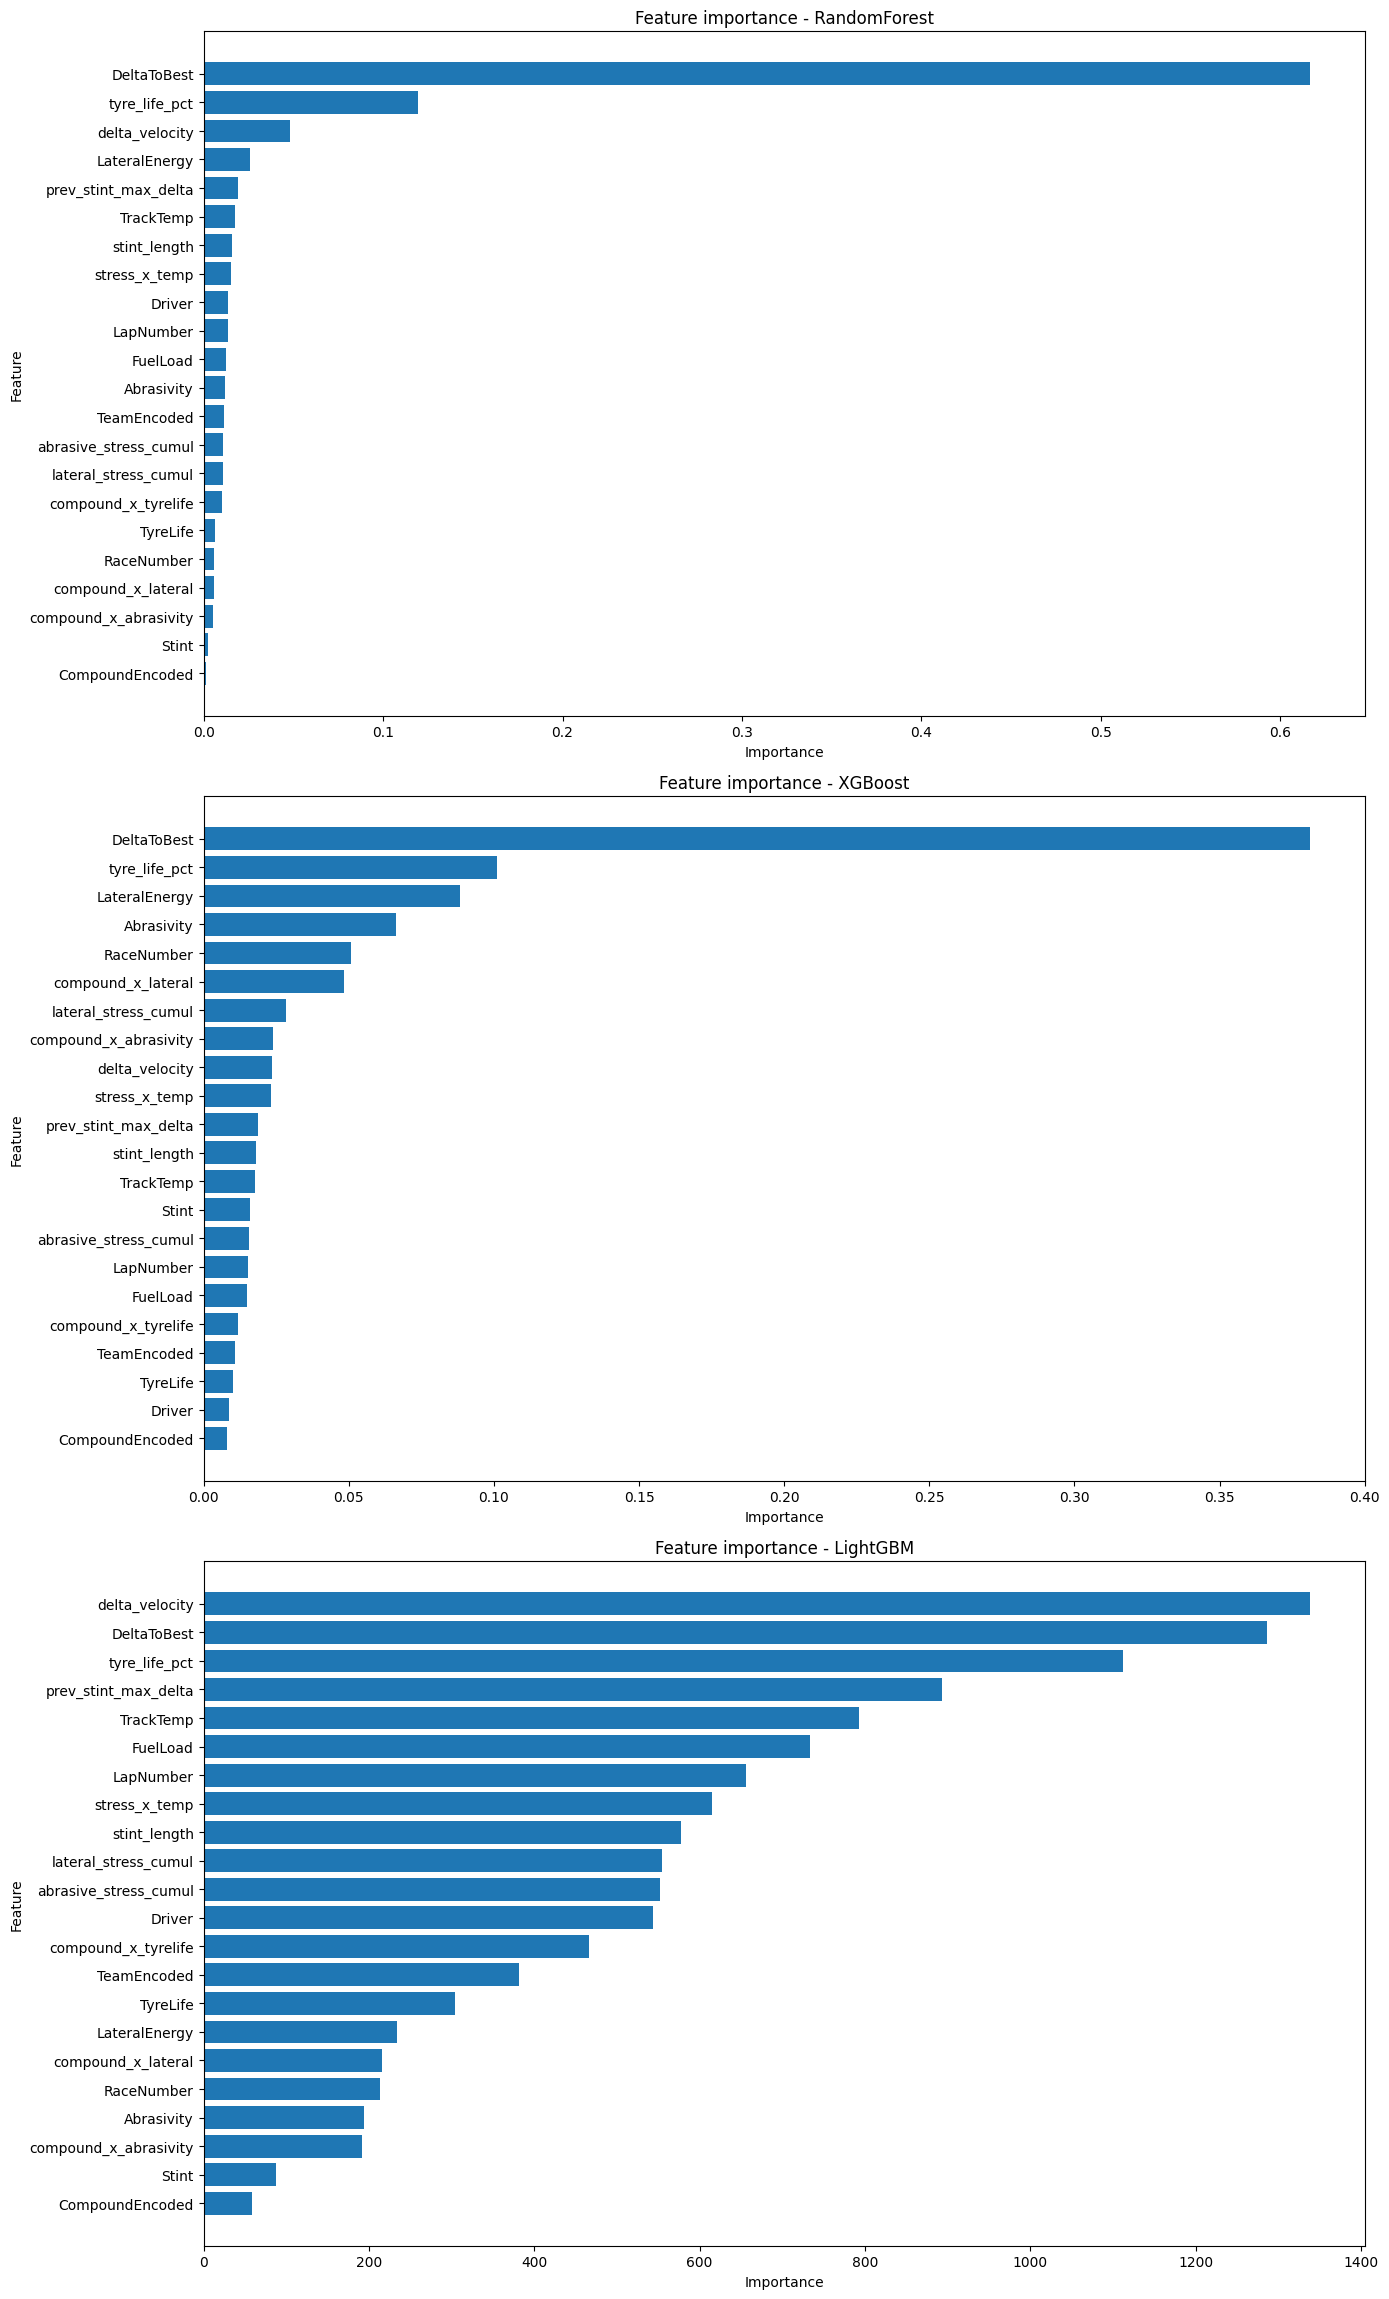

In [37]:
import matplotlib.pyplot as plt

feature_importances = {}

for model_name, fitted_model in models.items():
    importances = pd.Series(fitted_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False)
    feature_importances[model_name] = importances

importance_summary = pd.DataFrame({model_name: series for model_name, series in feature_importances.items()}).fillna(0)
importance_percent = importance_summary.div(importance_summary.sum(axis=0), axis=1).fillna(0) * 100

print('Full feature importance by model (raw values):')
for model_name in importance_summary.columns:
    print(f'\n=== {model_name} ===')
    print(importance_summary[model_name].sort_values(ascending=False).to_string())

print('\nFull feature importance by model (percent of total):')
for model_name in importance_percent.columns:
    print(f'\n=== {model_name} ===')
    print(importance_percent[model_name].sort_values(ascending=False).round(4).to_string())

fig, axes = plt.subplots(len(feature_importances), 1, figsize=(14, max(5, 0.35 * len(X_train.columns)) * len(feature_importances)))
if len(feature_importances) == 1:
    axes = [axes]

for ax, (model_name, series) in zip(axes, feature_importances.items()):
    ordered_series = series.sort_values(ascending=True)
    ax.barh(ordered_series.index, ordered_series.values, color='#1f77b4')
    ax.set_title(f'Feature importance - {model_name}')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()